In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# Image feature extraction
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv
from skimage import exposure

# Scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, log_loss
)
import time

# XGBoost
import xgboost as xgb

warnings.filterwarnings('ignore')
print("✅ All libraries loaded")


✅ All libraries loaded


In [2]:
DATASET_DIR  = Path("dataset")
RESULTS_DIR  = Path("results/ML_ensemble")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES  = ["healthy", "downey mildew"]
IMG_SIZE     = (128, 128)   # Resize for feature extraction
RANDOM_STATE = 42
TEST_SIZE    = 0.20

# LBP params
LBP_RADIUS   = 3
LBP_POINTS   = 8 * LBP_RADIUS

# HOG params
HOG_ORIENTATIONS  = 9
HOG_PIXELS_CELL   = (16, 16)
HOG_CELLS_BLOCK   = (2, 2)

print(f"Dataset  : {DATASET_DIR.resolve()}")
print(f"Results  : {RESULTS_DIR.resolve()}")


Dataset  : D:\vineyard disease\dataset
Results  : D:\vineyard disease\results\ML_ensemble


## 1. Handcrafted Feature Extraction

We extract **three types of features** from each image:
- **HOG** — captures edge orientations / shape
- **LBP** — captures local texture patterns
- **Color Histogram** — captures color distribution in HSV space

In [3]:
def extract_hog_features(img_rgb):
    """HOG on grayscale — captures shape/edge structure."""
    gray = rgb2gray(img_rgb)
    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_CELL,
        cells_per_block=HOG_CELLS_BLOCK,
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features

def extract_lbp_features(img_rgb, n_bins=64):
    """LBP histogram on grayscale — captures texture."""
    gray = (rgb2gray(img_rgb) * 255).astype(np.uint8)
    lbp  = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
    return hist

def extract_color_histogram(img_rgb, bins=32):
    """Color histogram in HSV space — captures disease-related color shifts."""
    hsv = rgb2hsv(img_rgb)
    feats = []
    for ch in range(3):   # H, S, V channels
        hist, _ = np.histogram(hsv[:, :, ch], bins=bins, range=(0, 1), density=True)
        feats.extend(hist)
    return np.array(feats)

def extract_all_features(img_path):
    """Load image and concatenate HOG + LBP + Color Histogram."""
    img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
    img_arr = np.array(img) / 255.0

    hog_feat   = extract_hog_features(img_arr)
    lbp_feat   = extract_lbp_features(img_arr)
    color_feat = extract_color_histogram(img_arr)

    return np.concatenate([hog_feat, lbp_feat, color_feat])


## 2. Build Feature Matrix for All Images

In [4]:
X_raw = []
y_raw = []
skipped = 0

print("Extracting features from all images...")
for label, cls in enumerate(CLASS_NAMES):
    cls_dir = DATASET_DIR / cls
    img_files = [p for p in cls_dir.glob("*")
                 if p.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')]
    for img_path in img_files:
        try:
            feat = extract_all_features(img_path)
            X_raw.append(feat)
            y_raw.append(label)
        except Exception as e:
            skipped += 1

X = np.array(X_raw)
y = np.array(y_raw)

print(f"\n✅ Feature extraction complete")
print(f"   Feature matrix : {X.shape}  ({X.shape[1]} dims per image)")
print(f"   Labels         : {y.shape}")


Extracting features from all images...

✅ Feature extraction complete
   Feature matrix : (2831, 1924)  (1924 dims per image)
   Labels         : (2831,)


## 3. Preprocessing & Train/Test Split

In [5]:
# Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional PCA to reduce dimensionality slightly for trees
pca    = PCA(n_components=150, random_state=RANDOM_STATE)
X_pca  = pca.fit_transform(X_scaled)
var_kept = pca.explained_variance_ratio_.cumsum()[-1] * 100
print(f"PCA: {X_scaled.shape[1]} → {X_pca.shape[1]} dims  |  Variance kept: {var_kept:.2f}%")

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")


PCA: 1924 → 150 dims  |  Variance kept: 78.13%
Train: 2264  |  Test: 567


## 4. Train XGBoost & Random Forest on Traditional Features

  MODEL: XGBoost
               precision    recall  f1-score   support

      healthy       0.96      0.92      0.94       280
downey mildew       0.93      0.97      0.95       287

     accuracy                           0.94       567
    macro avg       0.94      0.94      0.94       567
 weighted avg       0.94      0.94      0.94       567



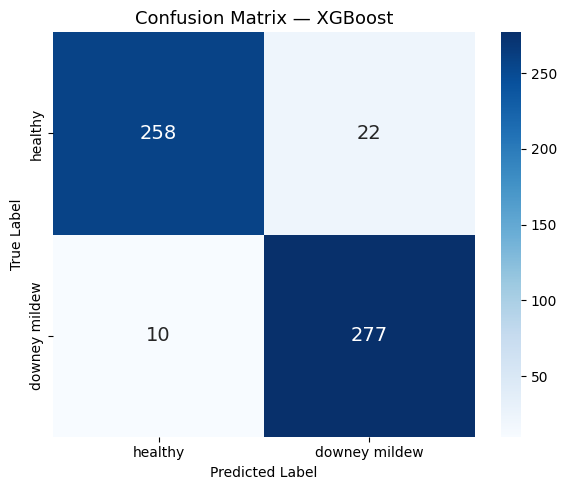

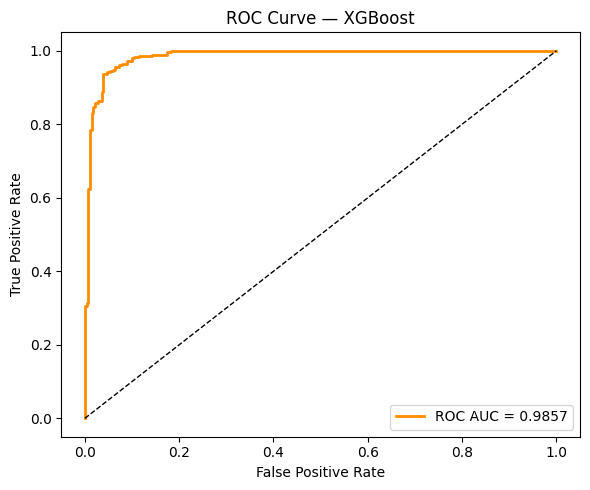

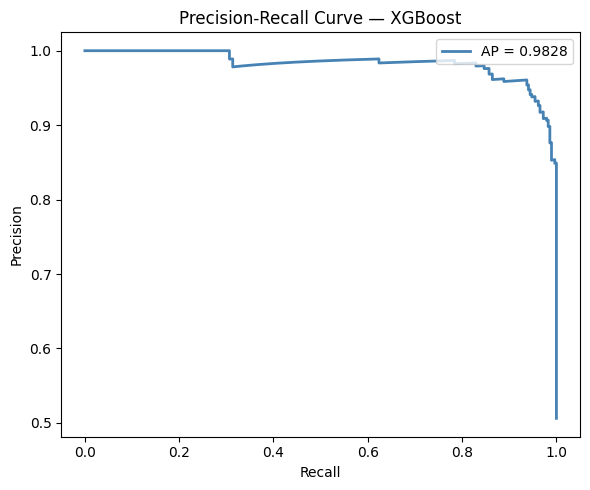

  MODEL: Random Forest
               precision    recall  f1-score   support

      healthy       0.96      0.86      0.91       280
downey mildew       0.88      0.97      0.92       287

     accuracy                           0.92       567
    macro avg       0.92      0.91      0.91       567
 weighted avg       0.92      0.92      0.92       567



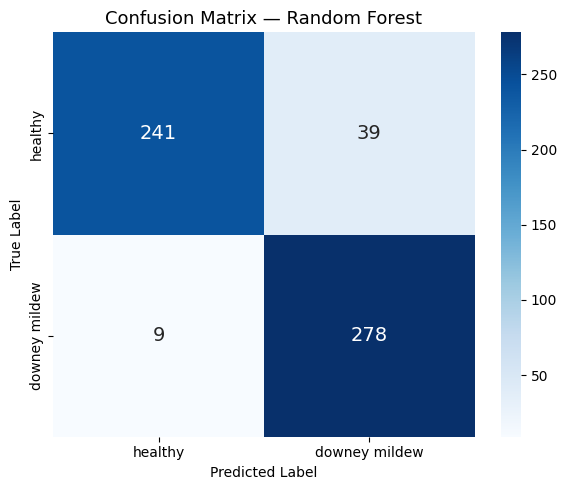

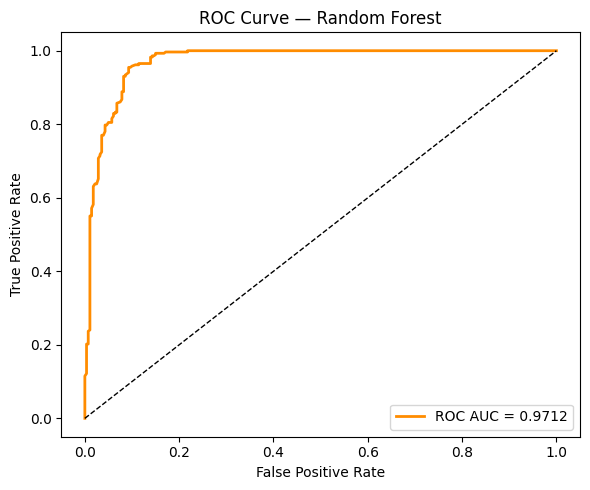

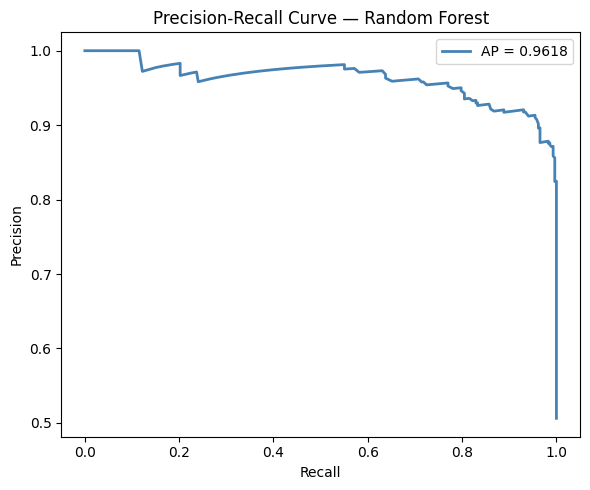

In [6]:
CLASS_NAMES_EVAL = CLASS_NAMES  # ['healthy', 'downey mildew']

def full_evaluate_traditional(name, y_true, y_pred, y_prob, class_names=CLASS_NAMES_EVAL):
    """Comprehensive evaluation matching the CNN pipeline style."""
    t_start = time.time()

    acc       = accuracy_score(y_true, y_pred)
    prec      = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec       = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    f1_macro  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    mcc       = matthews_corrcoef(y_true, y_pred)
    kappa     = cohen_kappa_score(y_true, y_pred)
    logloss   = log_loss(y_true, y_prob)
    roc_auc_v = roc_auc_score(y_true, y_prob)
    avg_prec  = average_precision_score(y_true, y_prob)

    # Confusion matrix derived metrics
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    inference_time = (time.time() - t_start) / len(y_true) * 1000  # ms per sample

    # ── 1. Classification Report
    print(f"{'='*60}")
    print(f"  MODEL: {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # ── 2. Confusion Matrix
    safe_name = name.replace(' ', '_').replace('(', '').replace(')', '')
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13)
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{safe_name}_confusion_matrix.png', dpi=150)
    plt.show()

    # ── 3. ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_val = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc_val:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{safe_name}_roc_curve.png', dpi=150)
    plt.show()

    # ── 4. Precision-Recall Curve
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(rec_curve, prec_curve, color='steelblue', lw=2, label=f'AP = {avg_prec:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve — {name}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{safe_name}_pr_curve.png', dpi=150)
    plt.show()

    metrics = {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision (W)': round(prec, 4),
        'Recall (W)': round(rec, 4),
        'F1 (Weighted)': round(f1, 4),
        'F1 (Macro)': round(f1_macro, 4),
        'ROC-AUC': round(roc_auc_v, 4),
        'Avg Precision': round(avg_prec, 4),
        'Sensitivity': round(sensitivity, 4),
        'Specificity': round(specificity, 4),
        'MCC': round(mcc, 4),
        'Cohen Kappa': round(kappa, 4),
        'Log Loss': round(logloss, 4),
        'Inf Time (ms)': round(inference_time, 2),
    }
    return metrics


# ── XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# ── Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500, n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

results_xgb = full_evaluate_traditional('XGBoost', y_test, y_pred_xgb, y_prob_xgb)
results_rf  = full_evaluate_traditional('Random Forest', y_test, y_pred_rf, y_prob_rf)


### 4a. Training vs Validation — Loss & Accuracy Curves

- **XGBoost**: per-round log-loss and accuracy tracked natively via `eval_set`.
- **Random Forest**: train/val log-loss & accuracy computed at every 25-tree increment using `warm_start`.

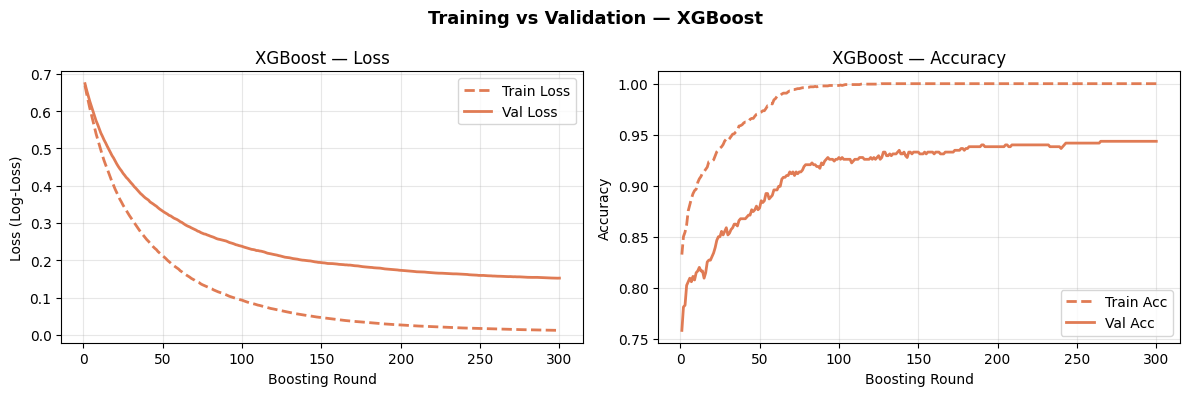

Saved results/ML_ensemble/XGBoost_training_curves.png


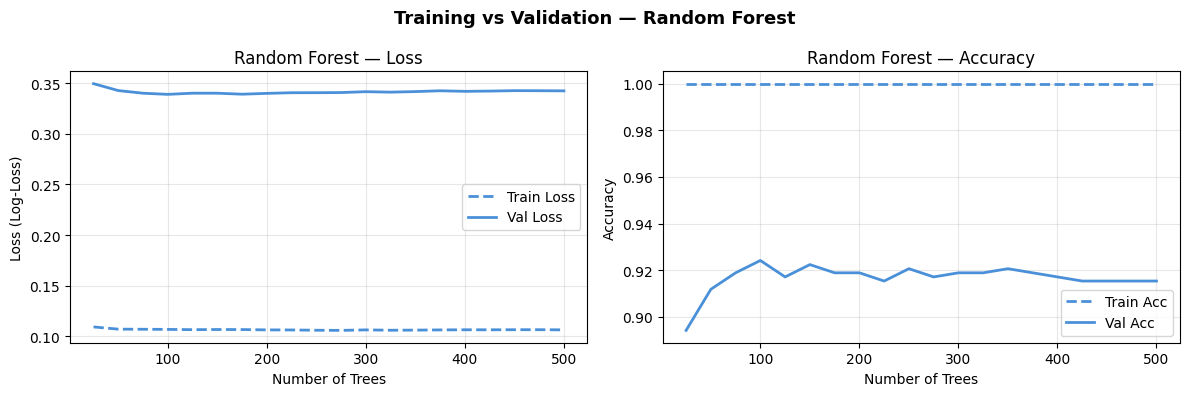

Saved results/ML_ensemble/RandomForest_training_curves.png

XGBoost       — best val loss: 0.1519  |  best val acc: 0.9436
Random Forest — best val loss: 0.3389  |  best val acc: 0.9242


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import log_loss, accuracy_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

# ════════════════════════════════════════════════════════════════════════════
# XGBoost — track Train / Val log-loss AND accuracy per boosting round
# ════════════════════════════════════════════════════════════════════════════
xgb_tracked = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    use_label_encoder=False, eval_metric=["logloss", "error"],
    random_state=RANDOM_STATE, verbosity=0
)
xgb_tracked.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
xgb_res = xgb_tracked.evals_result()
xgb_train_loss = xgb_res["validation_0"]["logloss"]
xgb_val_loss   = xgb_res["validation_1"]["logloss"]
xgb_train_acc  = [1 - e for e in xgb_res["validation_0"]["error"]]
xgb_val_acc    = [1 - e for e in xgb_res["validation_1"]["error"]]

# ════════════════════════════════════════════════════════════════════════════
# Random Forest — warm_start: add 25 trees at a time, record loss + accuracy
# ════════════════════════════════════════════════════════════════════════════
STEP      = 25
MAX_TREES = 500
tree_counts = list(range(STEP, MAX_TREES + 1, STEP))

rf_train_loss, rf_val_loss   = [], []
rf_train_acc,  rf_val_acc    = [], []

rf_warm = RandomForestClassifier(
    n_estimators=0, warm_start=True,
    n_jobs=-1, random_state=RANDOM_STATE
)
for n in tree_counts:
    rf_warm.set_params(n_estimators=n)
    rf_warm.fit(X_train, y_train)

    tr_prob = rf_warm.predict_proba(X_train)
    vl_prob = rf_warm.predict_proba(X_test)
    tr_pred = rf_warm.predict(X_train)
    vl_pred = rf_warm.predict(X_test)

    rf_train_loss.append(log_loss(y_train, tr_prob))
    rf_val_loss.append(log_loss(y_test,   vl_prob))
    rf_train_acc.append(accuracy_score(y_train, tr_pred))
    rf_val_acc.append(accuracy_score(y_test,   vl_pred))

# ════════════════════════════════════════════════════════════════════════════
# Plot helper — reusable function matching the CNN chart style
# ════════════════════════════════════════════════════════════════════════════
def plot_train_val_curves(model_name, x_vals, x_label,
                          train_loss, val_loss,
                          train_acc,  val_acc,
                          color, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ── Loss panel
    axes[0].plot(x_vals, train_loss, label="Train Loss",
                 color=color, linestyle="--", linewidth=2)
    axes[0].plot(x_vals, val_loss,   label="Val Loss",
                 color=color, linewidth=2)
    axes[0].set_title(f"{model_name} — Loss", fontsize=12)
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel("Loss (Log-Loss)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Accuracy panel
    axes[1].plot(x_vals, train_acc, label="Train Acc",
                 color=color, linestyle="--", linewidth=2)
    axes[1].plot(x_vals, val_acc,   label="Val Acc",
                 color=color, linewidth=2)
    axes[1].set_title(f"{model_name} — Accuracy", fontsize=12)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f"Training vs Validation — {model_name}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / save_name, dpi=150)
    plt.show()
    print(f"Saved results/ML_ensemble/{save_name}")

# ── XGBoost figure
plot_train_val_curves(
    model_name  = "XGBoost",
    x_vals      = list(range(1, len(xgb_train_loss) + 1)),
    x_label     = "Boosting Round",
    train_loss  = xgb_train_loss,
    val_loss    = xgb_val_loss,
    train_acc   = xgb_train_acc,
    val_acc     = xgb_val_acc,
    color       = "#E07B54",
    save_name   = "XGBoost_training_curves.png",
)

# ── Random Forest figure
plot_train_val_curves(
    model_name  = "Random Forest",
    x_vals      = tree_counts,
    x_label     = "Number of Trees",
    train_loss  = rf_train_loss,
    val_loss    = rf_val_loss,
    train_acc   = rf_train_acc,
    val_acc     = rf_val_acc,
    color       = "#4A90D9",
    save_name   = "RandomForest_training_curves.png",
)

# ── Print best validation scores
print(f"\nXGBoost       — best val loss: {min(xgb_val_loss):.4f}  |  best val acc: {max(xgb_val_acc):.4f}")
print(f"Random Forest — best val loss: {min(rf_val_loss):.4f}  |  best val acc: {max(rf_val_acc):.4f}")


## 5. Traditional Models — Summary Table & Comparison Chart


===== TRADITIONAL MODEL COMPARISON TABLE =====
               Accuracy  Precision (W)  Recall (W)  F1 (Weighted)  F1 (Macro)  ROC-AUC  Avg Precision  Sensitivity  Specificity     MCC  Cohen Kappa  Log Loss  Inf Time (ms)
Model                                                                                                                                                                        
XGBoost          0.9436         0.9443      0.9436         0.9435      0.9435   0.9857         0.9828       0.9652       0.9214  0.8878       0.8870    0.1521           0.05
Random Forest    0.9153         0.9199      0.9153         0.9151      0.9150   0.9712         0.9618       0.9686       0.8607  0.8351       0.8304    0.3424           0.04

Saved to results/ML_ensemble/ML_results.csv


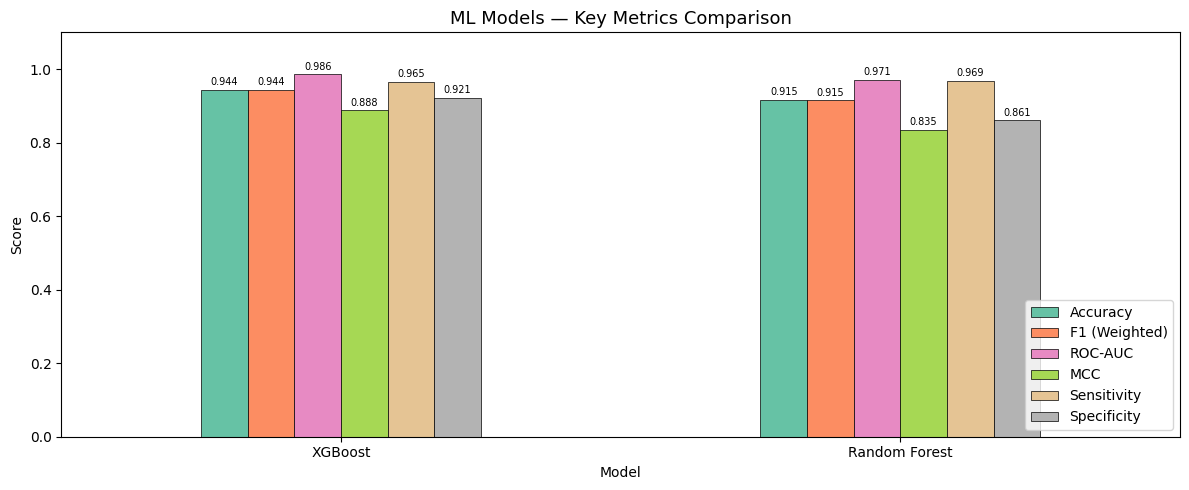

Saved ML_chart.png


In [8]:
# ── Save all traditional model metrics to CSV
trad_all_metrics = [results_xgb, results_rf]
df_trad = pd.DataFrame(trad_all_metrics).set_index('Model')

print("\n===== TRADITIONAL MODEL COMPARISON TABLE =====")
print(df_trad.to_string())

# Save for cross-notebook comparison
df_trad.to_csv(RESULTS_DIR / 'ML_results.csv')
print("\nSaved to results/ML_ensemble/ML_results.csv")

# Bar chart of key metrics
key_metrics = ['Accuracy', 'F1 (Weighted)', 'ROC-AUC', 'MCC', 'Sensitivity', 'Specificity']
df_plot = df_trad[key_metrics]
ax = df_plot.plot(kind='bar', figsize=(12, 5), rot=0, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_title('ML Models — Key Metrics Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'ML_comparison_chart.png', dpi=150)
plt.show()
print("Saved ML_chart.png")


## 6. Comparison: Traditional ML  vs  Fine-tuned CNN

Loads results from both model families and visualises them side-by-side:
- **Orange** — Traditional handcrafted features (HOG + LBP + Color Hist) + XGBoost / RF
- **Blue**   — Fine-tuned CNNs: ResNet50, EfficientNetB0, MobileNetV2 (from `downy_mildew_pipeline.ipynb`)

[OK] Loaded 3 CNN models from results\model_comparison.csv

  COMPARISON: ML (HOG+LBP+Color)  vs  Fine-tuned CNN
                Accuracy  F1 (Weighted)  ROC-AUC     MCC  Sensitivity  Specificity
Model                                                                             
XGBoost           0.9436         0.9435   0.9857  0.8878       0.9652       0.9214
Random Forest     0.9153         0.9151   0.9712  0.8351       0.9686       0.8607
ResNet50          0.9788         0.9788   0.9984  0.9577       0.9721       0.9857
EfficientNetB0    0.9859         0.9859   0.9985  0.9718       0.9860       0.9857
MobileNetV2       0.9765         0.9765   0.9986  0.9531       0.9674       0.9857

Saved results/ML_ensemble/ML_vs_cnn_comparison.csv


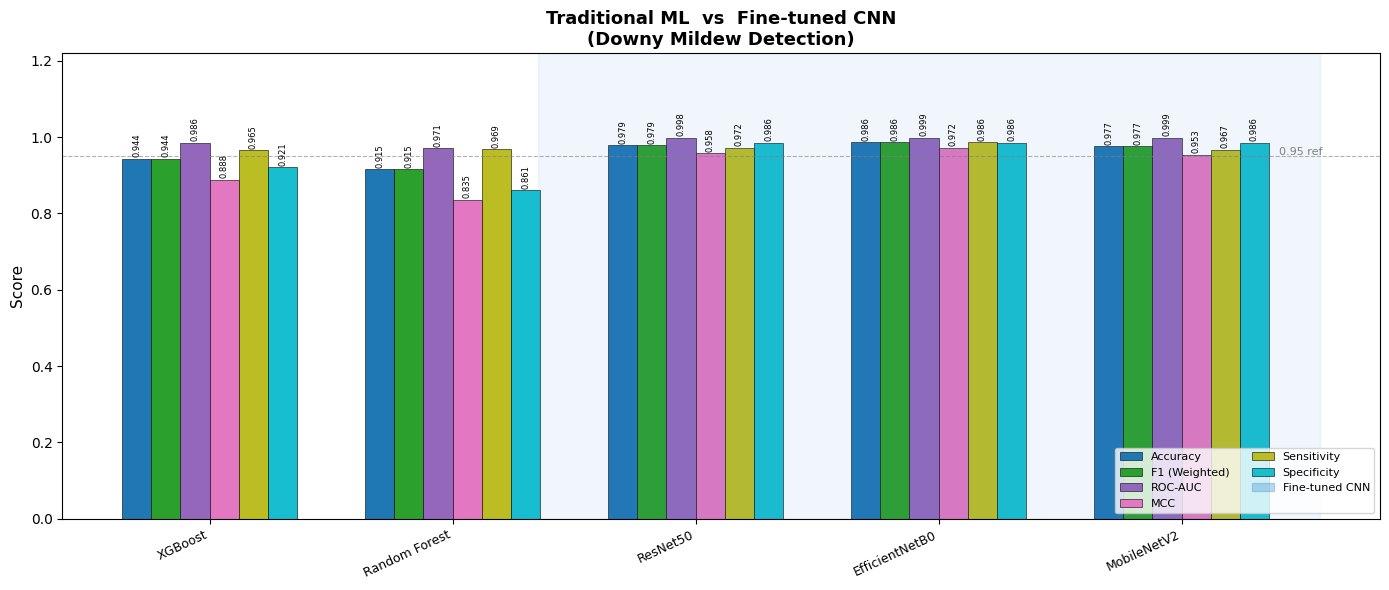

Saved results/ML_ensemble/ML_vs_cnn_chart.png

--- Best Model Per Category (by Accuracy) ---
  [Fine-tuned CNN]
    Model     : EfficientNetB0
    Accuracy  : 0.9859
    F1 (W)    : 0.9859
    ROC-AUC   : 0.9985
  [ML(HOG+LBP+Color)]
    Model     : XGBoost
    Accuracy  : 0.9436
    F1 (W)    : 0.9435
    ROC-AUC   : 0.9857

--- Overall Best Model ---
  EfficientNetB0  (Fine-tuned CNN)
  Accuracy : 0.9859  |  F1 (W): 0.9859  |  ROC-AUC: 0.9985


In [ ]:
# ── Load results from Traditional ML and Fine-tuned CNN ──────────────────────

KEY_METRICS = ["Accuracy", "F1 (Weighted)", "ROC-AUC", "MCC", "Sensitivity", "Specificity"]

# 1. Traditional model results (computed above in this notebook)
trad_df = pd.DataFrame([results_xgb, results_rf])
trad_df["Category"] = "ML(HOG+LBP+Color)"

# 2. Fine-tuned CNN results (from downy_mildew_pipeline.ipynb)
cnn_csv = Path("results/model_comparison.csv")
if cnn_csv.exists():
    cnn_df = pd.read_csv(cnn_csv)
    cnn_df["Category"] = "Fine-tuned CNN"
    print(f"[OK] Loaded {len(cnn_df)} CNN models from {cnn_csv}")
else:
    print("[WARNING] results/model_comparison.csv not found.")
    print("         Run downy_mildew_pipeline.ipynb first to include CNN results.")
    cnn_df = pd.DataFrame()

# ── Combine both groups ───────────────────────────────────────────────────────
frames = [f for f in [trad_df, cnn_df] if len(f) > 0]
full_df = pd.concat(frames, ignore_index=True)

available = [c for c in ["Model", "Category"] + KEY_METRICS if c in full_df.columns]
full_df = full_df[available].copy()
disp_cols = [c for c in KEY_METRICS if c in full_df.columns]

# ── Print comparison table ────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  COMPARISON: ML (HOG+LBP+Color)  vs  Fine-tuned CNN")
print("=" * 80)
print(full_df.set_index("Model")[disp_cols].to_string())

# Save CSV
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
full_df.to_csv(RESULTS_DIR / "ML_vs_cnn_comparison.csv", index=False)
print("\nSaved results/ML_ensemble/ML_vs_cnn_comparison.csv")

# ── Grouped Bar Chart ─────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
import numpy as np

CATEGORY_COLORS = {
    "Traditional (HOG+LBP+Color)": "#E07B54",
    "Fine-tuned CNN":               "#4A90D9",
}

n_models  = len(full_df)
n_metrics = len(disp_cols)
x         = np.arange(n_models)
bar_w     = 0.12

fig, ax = plt.subplots(figsize=(14, 6))
palette = plt.cm.get_cmap("tab10", n_metrics)

# Draw metric bars
for j, metric in enumerate(disp_cols):
    bars = ax.bar(x + j * bar_w, full_df[metric], width=bar_w,
                  label=metric, color=palette(j), edgecolor="black", linewidth=0.4)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.004,
                f"{h:.3f}", ha="center", va="bottom", fontsize=6, rotation=90)

# Category background shading
for cat, color in CATEGORY_COLORS.items():
    idxs = full_df[full_df["Category"] == cat].index.tolist()
    if idxs:
        start = x[idxs[0]] - 0.35
        end   = x[idxs[-1]] + bar_w * n_metrics + 0.15
        ax.axvspan(start, end, alpha=0.08, color=color)

ax.set_xticks(x + bar_w * (n_metrics / 2 - 0.5))
ax.set_xticklabels(full_df["Model"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.22)
ax.set_title(
    "Traditional ML  vs  Fine-tuned CNN\n(Downy Mildew Detection)",
    fontsize=13, fontweight="bold"
)
ax.axhline(0.95, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(n_models - 0.3, 0.953, "0.95 ref", color="grey", fontsize=8)

# Legend: metric colours + category shading
metric_handles, metric_labels = ax.get_legend_handles_labels()
cat_patches = [
    mpatches.Patch(color=CATEGORY_COLORS[cat], alpha=0.35, label=cat)
    for cat in CATEGORY_COLORS
    if cat in full_df["Category"].values
]
ax.legend(
    handles=metric_handles + cat_patches,
    labels=metric_labels + [p.get_label() for p in cat_patches],
    loc="lower right", fontsize=8, ncol=2
)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "ML_vs_cnn_chart.png", dpi=150)
plt.show()
print("Saved results/ML_ensemble/ML_vs_cnn_chart.png")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n--- Best Model Per Category (by Accuracy) ---")
for cat, grp in full_df.groupby("Category"):
    best = grp.loc[grp["Accuracy"].idxmax()]
    print(f"  [{cat}]")
    print(f"    Model     : {best['Model']}")
    print(f"    Accuracy  : {best['Accuracy']:.4f}")
    print(f"    F1 (W)    : {best['F1 (Weighted)']:.4f}")
    print(f"    ROC-AUC   : {best['ROC-AUC']:.4f}")

print("\n--- Overall Best Model ---")
best_idx = full_df["Accuracy"].idxmax()
b = full_df.loc[best_idx]
print(f"  {b['Model']}  ({b['Category']})")
print(f"  Accuracy : {b['Accuracy']:.4f}  |  F1 (W): {b['F1 (Weighted)']:.4f}  |  ROC-AUC: {b['ROC-AUC']:.4f}")
